# DengAI: a reproducible leaderboard candidate
### City-specific ensembles, chronological validation, and honest diagnostics

**Question:** Can climate and seasonal history predict weekly `total_cases` in San Juan (`sj`) and Iquitos (`iq`)? This could inform staffing, supplies, and surveillance planning; MAE alone cannot demonstrate a health or cost benefit.

**Deliverable:** Run all cells to compare models, select a blend separately for each city, evaluate a held-back historical period, and generate `artifacts/submission.csv`. Lower MAE is better. No leaderboard rank is promised: this notebook has no hidden test labels or authenticated leaderboard results.

The existing repository README reports **22.5 hidden-test MAE** for its forest submission. That is a user-project claim, not a score for this notebook. Here its architecture is rebuilt as a candidate and reference; existing files are never overwritten.

**Sources:** [official task, metric, test horizon, submission format, and rules](https://www.drivendata.org/competitions/44/dengai-predicting-disease-spread/page/82/); [organizer's benchmark](https://blog.drivendata.org/blog/dengue-benchmark). Only the supplied competition CSVs are model inputs. The task supplies weather for the prediction weeks, so these are weather-conditional case estimates, not operational forecasts of unknown future weather.

**Course rubric:** sections below cover problem/impact (4), pandas/X/y (2), motivated preparation (5), Seaborn EDA (4), validation/model tuning (7), results/limitations (8), and presentation clarity (10). Slide metadata is included. Add actual team contributions and a prerecorded presentation link before LMS submission.

## 1. Reproducible setup
Use Python 3.11+ and `pip install -r requirements.txt` from this folder. All modeling code is in this notebook; the builder script is optional. The default search is intentionally bounded (20 candidates per city, five development folds); allow several minutes on a laptop. Set `QUICK = True` only for a smoke run, not for comparing published results. Re-running overwrites only this folder's generated artifacts.

In [1]:
from pathlib import Path
import os, sys, json, hashlib, platform, time, importlib.metadata

def locate_project():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for candidate in [base, base / 'DengAI']:
            if (candidate / 'data/dengue_features_train.csv').is_file():
                return candidate.resolve()
    raise FileNotFoundError('Open the notebook from DengAI, its parent, or this notebook folder.')

ROOT = locate_project()
HERE = ROOT / 'leaderboard_notebook'
OUT = HERE / 'artifacts'
FIG = OUT / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(OUT / '.mplconfig'))
os.environ.setdefault('XDG_CACHE_HOME', str(OUT / '.cache'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
import joblib

QUICK = False
SEED = 42
THREADS = 4
TREES = 60 if QUICK else 500
ITERATIONS = 80 if QUICK else 500
sns.set_theme(style='whitegrid', palette='colorblind', context='notebook')
plt.rcParams.update({'figure.figsize': (12, 4), 'figure.dpi': 110})
KEYS = ['city', 'year', 'weekofyear']
DATE, TARGET = 'week_start_date', 'total_cases'
def cases(x):
    x = np.asarray(x, dtype=float)
    assert np.isfinite(x).all(), 'Non-finite model prediction'
    return np.floor(np.maximum(x, 0) + .5).astype('int64')
def mae(y, p):
    return float(mean_absolute_error(y, cases(p)))
def savefig(name):
    plt.tight_layout()
    plt.savefig(FIG / f'{name}.png', bbox_inches='tight')
    plt.show()
versions = {p: importlib.metadata.version(p) for p in
            ['numpy','pandas','scikit-learn','catboost','lightgbm','seaborn','matplotlib','nbformat','nbclient','joblib']}
print('Python:', platform.python_version(), '| full search:', not QUICK)
display(pd.Series(versions, name='version').to_frame())

Matplotlib is building the font cache; this may take a moment.


Python: 3.14.3 | full search: True


,version
numpy,2.4.2
pandas,3.0.1
scikit-learn,1.8.0
catboost,1.2.10
lightgbm,4.7.0
seaborn,0.13.2
matplotlib,3.10.8
nbformat,5.10.4
nbclient,0.11.0
joblib,1.5.3


## 2. Load, audit, and split X / y
Join labels by all three keys, not by row position. Keep chronological row order within city: the supplied date field contains some year-boundary steps of eight or nine days, so lag *k* means *k observations*. Splitting on dates avoids calendar-key anomalies. City is handled by separate models, so no arbitrary numeric city encoding is needed.

In [2]:
DATA = ROOT / 'data'
raw_train = pd.read_csv(DATA / 'dengue_features_train.csv', parse_dates=[DATE])
raw_test = pd.read_csv(DATA / 'dengue_features_test.csv', parse_dates=[DATE])
labels = pd.read_csv(DATA / 'dengue_labels_train.csv')
template = pd.read_csv(DATA / 'submission_format.csv')
for f in [raw_train, raw_test, labels, template]:
    assert not f.duplicated(KEYS).any()
assert raw_train[KEYS].merge(raw_test[KEYS], on=KEYS).empty
assert set(raw_train.city) == set(raw_test.city) == {'sj', 'iq'}
assert raw_test[KEYS].equals(template[KEYS])
train = raw_train.merge(labels, on=KEYS, validate='one_to_one', how='left')
assert len(train) == len(labels) and train[TARGET].notna().all()
assert (train[TARGET] >= 0).all() and (train[TARGET] % 1 == 0).all()
train = train.sort_values(['city', DATE]).reset_index(drop=True)
X, y = train.drop(columns=TARGET).copy(), train[TARGET].copy()
CLIMATE = [c for c in raw_train.columns if c not in KEYS + [DATE]]
city_data, audit = {}, []
for city in ['sj', 'iq']:
    tr = train[train.city.eq(city)].reset_index(drop=True)
    te = raw_test[raw_test.city.eq(city)].sort_values(DATE).reset_index(drop=True)
    assert tr[DATE].notna().all() and te[DATE].notna().all()
    assert tr[DATE].is_unique and te[DATE].is_unique
    assert tr[DATE].max() < te[DATE].min()
    steps = pd.concat([tr[DATE], te[DATE]]).diff().dropna().dt.days
    assert steps.between(7, 9).all()
    h = len(te)
    city_data[city] = {'train': tr, 'test': te, 'horizon': h, 'dev_end': len(tr)-h}
    audit.append(dict(city=city, train_rows=len(tr), test_rows=h,
                      first=tr[DATE].min().date(), last=tr[DATE].max().date(),
                      mean_cases=tr[TARGET].mean(), maximum=tr[TARGET].max(),
                      non_7_day_steps=int(steps.ne(7).sum())))
print('X:', X.shape, ' y:', y.shape, ' test:', raw_test.shape)
display(pd.DataFrame(audit).round(2))
display(X.head(3))

X: (1456, 24)  y: (1456,)  test: (416, 24)


,city,train_rows,test_rows,first,last,mean_cases,maximum,non_7_day_steps
0,sj,936,260,1990-04-30,2008-04-22,34.18,461,23
1,iq,520,156,2000-07-01,2010-06-25,7.57,116,13


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,...,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
0,iq,2000,26,2000-07-01,0.192886,0.132257,0.340886,0.247200,25.41,296.740000,...,43.19,92.418571,25.41,16.651429,8.928571,26.4,10.775000,32.5,20.7,3.0
1,iq,2000,27,2000-07-08,0.216833,0.276100,0.289457,0.241657,60.61,296.634286,...,46.00,93.581429,60.61,16.862857,10.314286,26.9,11.566667,34.0,20.8,55.6
2,iq,2000,28,2000-07-15,0.176757,0.173129,0.204114,0.128014,55.52,296.415714,...,64.77,95.848571,55.52,17.120000,7.385714,26.8,11.466667,33.0,20.7,38.1


## 3. Development-only exploratory analysis
Reserve the final **260 SJ weeks / 156 IQ weeks** for a historical audit. Use only earlier rows for exploratory plots and model selection. Existing notebooks in this workspace have already studied some of these periods, so this is a **retrospective held-back audit, not a previously unseen test**. The genuinely unseen competition labels remain the final judge.

Look for differences in city scale, seasonal peaks, long-term regime changes, missing sensors, and skewed counts. The plots motivate separate models, cyclical features, missing-value treatment, and both absolute-error and count-model losses. Correlation is descriptive, not evidence that weather causes an outbreak.

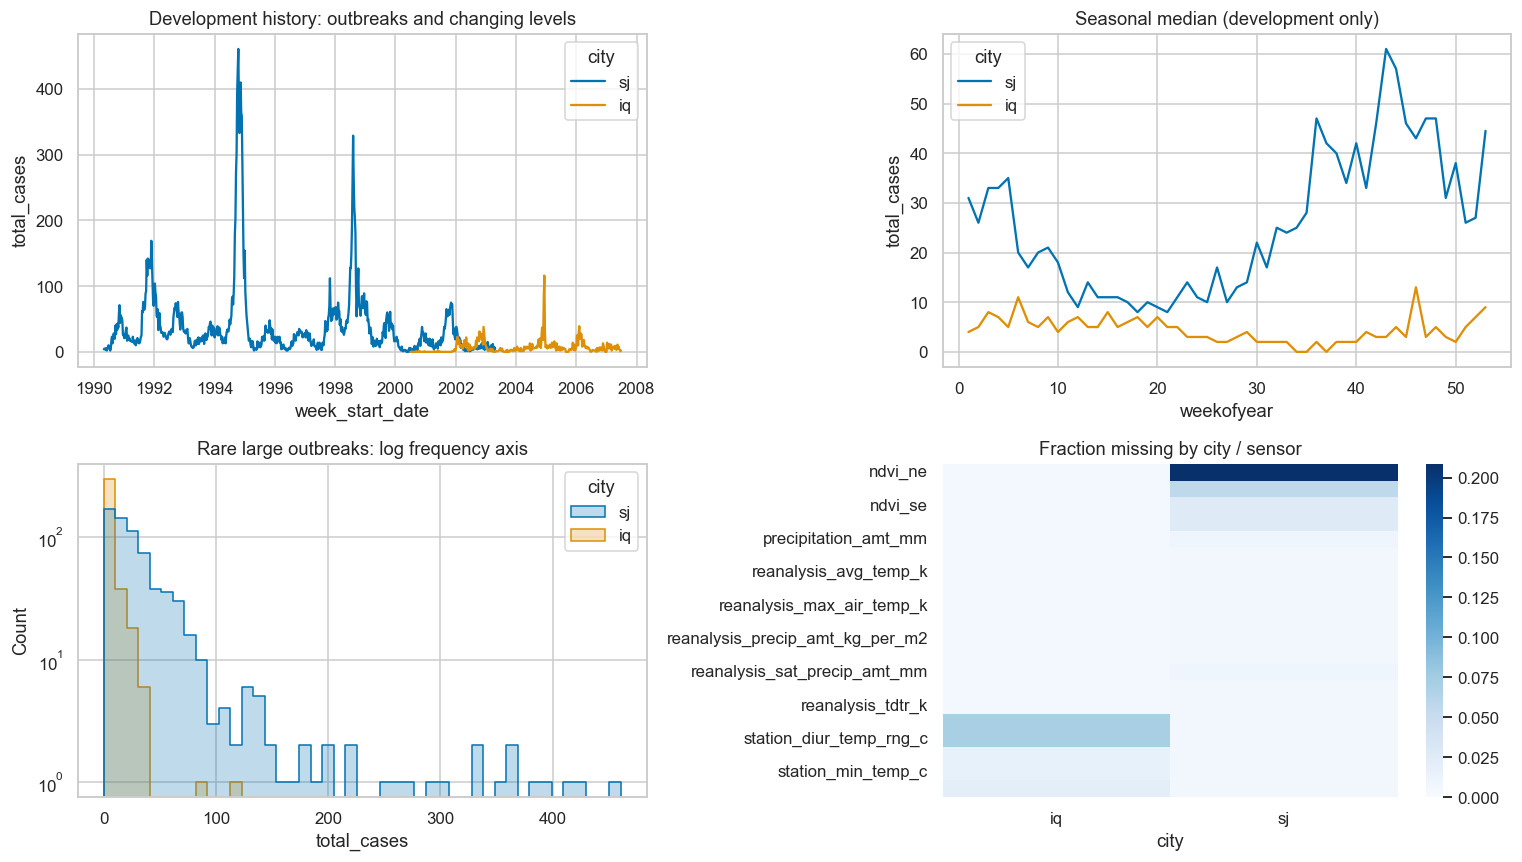

,mean,median,std,max,variance_to_mean
city,,,,,
iq,6.54,4.0,10.09,116,15.55
sj,38.66,23.0,57.42,461,85.30


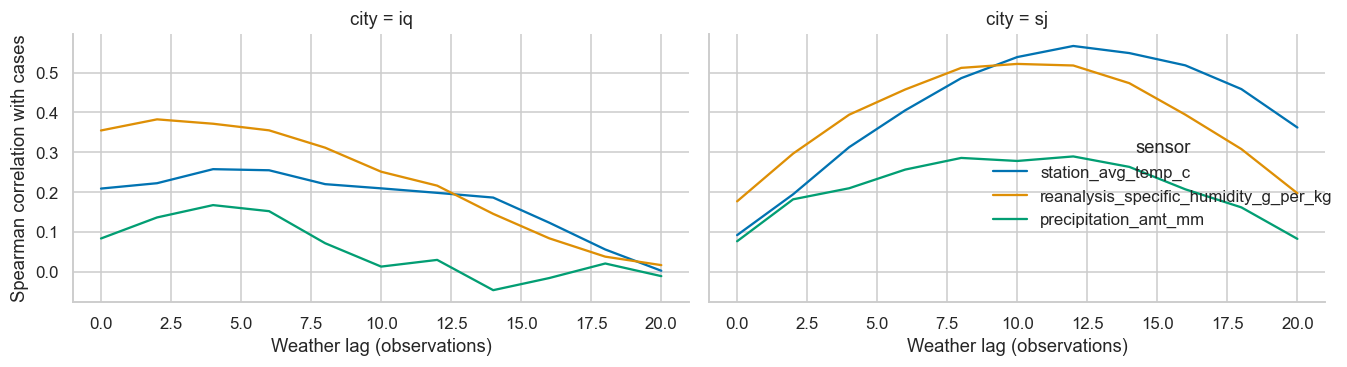

In [3]:
dev = pd.concat([v['train'].iloc[:v['dev_end']] for v in city_data.values()], ignore_index=True)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sns.lineplot(data=dev, x=DATE, y=TARGET, hue='city', ax=axes[0,0])
axes[0,0].set_title('Development history: outbreaks and changing levels')
sns.lineplot(data=dev, x='weekofyear', y=TARGET, hue='city', estimator='median', errorbar=None, ax=axes[0,1])
axes[0,1].set_title('Seasonal median (development only)')
sns.histplot(data=dev, x=TARGET, hue='city', bins=45, element='step', ax=axes[1,0])
axes[1,0].set_yscale('log')
axes[1,0].set_title('Rare large outbreaks: log frequency axis')
missing = dev.groupby('city')[CLIMATE].agg(lambda s: s.isna().mean()).T
sns.heatmap(missing, cmap='Blues', vmin=0, ax=axes[1,1])
axes[1,1].set_title('Fraction missing by city / sensor')
savefig('01_development_eda')
summary = dev.groupby('city')[TARGET].agg(['mean','median','std','max'])
summary['variance_to_mean'] = dev.groupby('city')[TARGET].var() / summary['mean']
display(summary.round(2))

lag_rows = []
for city, frame in dev.groupby('city'):
    for col in ['station_avg_temp_c','reanalysis_specific_humidity_g_per_kg','precipitation_amt_mm']:
        for lag in range(0, 21, 2):
            lag_rows.append({'city':city, 'sensor':col, 'lag':lag,
                             'spearman':frame[TARGET].corr(frame[col].shift(lag), method='spearman')})
lag_corr = pd.DataFrame(lag_rows)
g = sns.relplot(data=lag_corr, x='lag', y='spearman', hue='sensor', col='city', kind='line', height=3.5, aspect=1.3)
g.set_axis_labels('Weather lag (observations)', 'Spearman correlation with cases')
savefig('02_lag_correlations')

## 4. Features with a clear availability contract

**What the EDA shows:** San Juan has a much stronger late-year seasonal rise and
larger epidemic spikes than Iquitos. Its typical week and extreme outbreak
weeks have very different scales; neither a constant baseline nor squared
error alone is an adequate model-selection strategy. San Juan's northeast
vegetation sensor has especially frequent gaps, so deleting incomplete rows
would disproportionately discard its history. Both cities have a long right
tail in case counts. These observations motivate separate city models,
seasonal harmonics, explicit missingness handling, and losses compared in
original count units. Lag correlations motivate weather memory but do not
justify selecting a single causal delay from these small samples.

| Transformation | Motivation and leakage control |
|---|---|
| Four sine/cosine harmonics of week | Smooth cyclic seasonality; week 53 wraps naturally. |
| Raw climate, vegetation mean/spread, temperature range | Environmental summaries and interactions; quantities available in supplied test rows. |
| Climate lags 1–20; trailing means / variability | Allow delayed associations; every rolling window is shifted by one row first. |
| Missing flags, forward fill limited to 3 rows | Preserve missingness; no backward fill or future interpolation. Remaining medians are fitted inside each training fold. |
| Compact / extended feature sets | Compare a restrained feature set with richer weather memory. Drop duplicate precipitation from new sets. |
| Calendar year only in reference | Reproduce existing architecture; new sets avoid relying on a tree extrapolating year. |
| No case-count lags or global target encodings | No held-out or test labels are ever needed to construct features. |

`log1p` forest targets reduce outbreak influence; MAE-trained boosting targets the conditional median directly; Poisson/Tweedie models provide a different count-sensitive bias for blending. All are judged in original case units **after the same integer rounding used for submission**. Negative predictions are clipped to zero.

In [4]:
MEMORY = ['station_avg_temp_c','station_min_temp_c','station_max_temp_c','station_precip_mm',
          'reanalysis_relative_humidity_percent','reanalysis_specific_humidity_g_per_kg',
          'reanalysis_dew_point_temp_k','precipitation_amt_mm','reanalysis_precip_amt_kg_per_m2']
CORE = ['station_avg_temp_c','reanalysis_specific_humidity_g_per_kg',
        'reanalysis_relative_humidity_percent','precipitation_amt_mm']
NDVI = ['ndvi_ne','ndvi_nw','ndvi_se','ndvi_sw']

def features(frame, kind='compact'):
    assert frame[DATE].is_monotonic_increasing
    # Explicit allowlist: TARGET and arbitrary numeric metadata cannot enter X.
    raw = frame[CLIMATE].astype(float)
    weather = raw if kind == 'reference' else raw.ffill(limit=3)
    week = frame.weekofyear.astype(float)
    d = {'weekofyear': week}
    if kind == 'reference':
        d['year'] = frame.year.astype(float)
    for k in range(1, 5):
        d[f'week_sin_{k}'] = np.sin(2*np.pi*k*week/52)
        d[f'week_cos_{k}'] = np.cos(2*np.pi*k*week/52)
    for col in CLIMATE:
        if kind != 'reference' and col == 'reanalysis_sat_precip_amt_mm':
            continue
        d[col] = weather[col]
        if kind != 'reference':
            d[f'{col}__missing'] = raw[col].isna().astype(float)
    d['ndvi_mean'] = weather[NDVI].mean(axis=1)
    d['ndvi_std'] = weather[NDVI].std(axis=1)
    d['station_temp_range'] = weather.station_max_temp_c - weather.station_min_temp_c
    d['reanalysis_temp_range'] = weather.reanalysis_max_air_temp_k - weather.reanalysis_min_air_temp_k
    d['temperature_humidity_interaction'] = weather.station_avg_temp_c * weather.reanalysis_relative_humidity_percent
    memory = MEMORY if kind in ['extended','reference'] else CORE
    lags = (1,2,4,8,12,16) if kind == 'reference' else ((2,4,8,12) if kind == 'compact' else (1,2,4,6,8,10,12,16,20))
    windows = (2,4,8,12,16) if kind == 'reference' else (4,8,12,20)
    for col in memory:
        s = weather[col]
        for lag in lags:
            d[f'{col}__lag_{lag}'] = s.shift(lag)
        for window in windows:
            d[f'{col}__past_mean_{window}'] = s.shift(1).rolling(window).mean()
        if kind != 'reference':
            d[f'{col}__past_std_8'] = s.shift(1).rolling(8).std()
            d[f'{col}__anomaly_12'] = s - s.shift(1).rolling(12).mean()
    return pd.DataFrame(d, index=frame.index).replace([np.inf,-np.inf],np.nan)

for city, v in city_data.items():
    combined = pd.concat([v['train'].drop(columns=TARGET), v['test']], ignore_index=True)
    v['features'] = {kind:features(combined,kind) for kind in ['compact','extended','reference']}
    # Future perturbations cannot change a feature in the observed prefix.
    cut = v['dev_end']
    perturbed = combined.copy()
    perturbed.loc[cut:, CLIMATE] = 9999.0
    for kind, matrix in v['features'].items():
        pd.testing.assert_frame_equal(matrix.iloc[:cut], features(perturbed,kind).iloc[:cut])
        poisoned = combined.assign(total_cases=np.arange(len(combined))*1000)
        pd.testing.assert_frame_equal(matrix, features(poisoned,kind))
    assert all(TARGET not in f.columns for f in v['features'].values())
print('Passed: target independence, city isolation by construction, and future-weather perturbation checks.')
display(pd.DataFrame({c:{k:f.shape[1] for k,f in v['features'].items()} for c,v in city_data.items()}))

Passed: target independence, city isolation by construction, and future-weather perturbation checks.


,sj,iq
compact,92,92
extended,187,187
reference,134,134


## 5. Chronological validation and a fixed search protocol

**Metric:** MAE = mean(|observed − rounded prediction|), in cases/week. Also report city-specific scores, bias, and outbreak error. The final pooled score weights SJ/IQ by **260/416 and 156/416**, matching the submission, rather than giving the cities equal weight.

**Development:** four expanding 52-week folds ending before the held-back block, plus one earlier multi-year fold of the city's test horizon (260/156 weeks). The multi-year fold overlaps some annual validation dates; these are different forecast-origin experiments, **not independent samples**. The long fold gets half the selection weight. Score = 0.5 × mean annual MAE + 0.5 × long-horizon MAE + 0.1 × annual MAE standard deviation. This mildly penalizes unstable candidates.

**Selection:** test a bounded hyperparameter grid, then two-model convex blends of the top four candidates at weights 0.25/0.5/0.75. A blend must improve the objective by at least 0.1 cases to replace the best single model. Freeze the choice before the final historical audit. This avoids using audit labels for early stopping, fitting medians, weighting, or model selection. All models have fixed iteration counts; no hidden-test tuning or random K-fold split.

In [5]:
fold_rows = []
for city,v in city_data.items():
    end, h = v['dev_end'], v['horizon']
    folds = [(f'annual_{i+1}',s,s+52) for i,s in enumerate(range(end-208,end,52))]
    folds.append(('long_horizon', end-h, end))
    assert min(s for _,s,_ in folds) >= 104
    v['folds'] = folds
    for name,start,stop in [*folds, ('audit',end,len(v['train']))]:
        assert v['train'][DATE].iloc[start-1] < v['train'][DATE].iloc[start]
        fold_rows.append(dict(city=city,fold=name,train_n=start,valid_n=stop-start,
                              train_end=str(v['train'][DATE].iloc[start-1].date()),
                              valid_start=str(v['train'][DATE].iloc[start].date()),
                              valid_end=str(v['train'][DATE].iloc[stop-1].date())))
fold_table = pd.DataFrame(fold_rows)
fold_table.to_csv(OUT / 'folds.csv', index=False)
display(fold_table)

specs = [dict(name='city_median', family='median', kind='compact'),
         dict(name='seasonal_median', family='seasonal', kind='compact'),
         dict(name='reference_forest', family='reference', kind='reference')]
for kind in ['compact','extended']:
    specs.append(dict(name=f'rf_log_{kind}', family='rf_log', kind=kind, leaf=5))
    specs.append(dict(name=f'extra_poisson_{kind}', family='extra', kind=kind, leaf=8))
for loss in ['MAE','Poisson']:
    for depth in [3,5]:
        specs.append(dict(name=f'cat_{loss.lower()}_d{depth}', family='cat', kind='compact', loss=loss, depth=depth))
for loss in ['regression_l1','tweedie']:
    for leaves,leaf in [(7,20),(7,50),(15,20)]:
        specs.append(dict(name=f'lgb_{loss}_l{leaves}_n{leaf}', family='lgb', kind='extended', loss=loss, leaves=leaves, leaf=leaf))
for family in ['cat','lgb']:
    specs.append(dict(name=f'{family}_recent_mae', family=family, kind='compact',
                      loss='MAE' if family=='cat' else 'regression_l1', depth=3, leaves=7, leaf=20, half_life=260))
specs.append(dict(name='cat_mae_extended', family='cat', kind='extended', loss='MAE', depth=4))
if QUICK:
    specs = [s for s in specs if s['name'] in ['city_median','seasonal_median','reference_forest','rf_log_compact','cat_mae_d3','lgb_regression_l1_l7_n20']]
SPEC = {s['name']:s for s in specs}
display(pd.DataFrame(specs).fillna('—'))

,city,fold,train_n,valid_n,train_end,valid_start,valid_end
0,sj,annual_1,468,52,1999-04-23,1999-04-30,2000-04-22
1,sj,annual_2,520,52,2000-04-22,2000-04-29,2001-04-23
2,sj,annual_3,572,52,2001-04-23,2001-04-30,2002-04-23
3,sj,annual_4,624,52,2002-04-23,2002-04-30,2003-04-23
4,sj,long_horizon,416,260,1998-04-23,1998-04-30,2003-04-23
5,sj,audit,676,260,2003-04-23,2003-04-30,2008-04-22
6,iq,annual_1,156,52,2003-06-25,2003-07-02,2004-06-24
7,iq,annual_2,208,52,2004-06-24,2004-07-01,2005-06-25
8,iq,annual_3,260,52,2005-06-25,2005-07-02,2006-06-25
9,iq,annual_4,312,52,2006-06-25,2006-07-02,2007-06-25


,name,family,kind,leaf,loss,depth,leaves,half_life
0,city_median,median,compact,—,—,—,—,—
1,seasonal_median,seasonal,compact,—,—,—,—,—
2,reference_forest,reference,reference,—,—,—,—,—
3,rf_log_compact,rf_log,compact,5.0,—,—,—,—
4,extra_poisson_compact,extra,compact,8.0,—,—,—,—
5,rf_log_extended,rf_log,extended,5.0,—,—,—,—
6,extra_poisson_extended,extra,extended,8.0,—,—,—,—
7,cat_mae_d3,cat,compact,—,MAE,3.0,—,—
8,cat_mae_d5,cat,compact,—,MAE,5.0,—,—
9,cat_poisson_d3,cat,compact,—,Poisson,3.0,—,—


In [6]:
def estimator(s, city):
    family = s['family']
    if family in ['reference','rf_log','extra']:
        log = family=='rf_log' or (family=='reference' and city=='iq')
        cls = RandomForestRegressor if log else ExtraTreesRegressor
        model = cls(n_estimators=TREES, min_samples_leaf=s.get('leaf',5),
                    max_features=.5 if log else 1., criterion='squared_error' if log else 'poisson',
                    n_jobs=THREADS, random_state=SEED)
        pipe = make_pipeline(SimpleImputer(strategy='median', keep_empty_features=True),model)
        return TransformedTargetRegressor(regressor=pipe,func=np.log1p,inverse_func=np.expm1) if log else pipe
    if family=='cat':
        return CatBoostRegressor(iterations=ITERATIONS,depth=s['depth'],learning_rate=.035,
                                 loss_function=s['loss'],l2_leaf_reg=10,random_seed=SEED,
                                 thread_count=THREADS,verbose=False,allow_writing_files=False)
    if family=='lgb':
        return LGBMRegressor(n_estimators=ITERATIONS,learning_rate=.025,objective=s['loss'],
                             num_leaves=s['leaves'],min_child_samples=s['leaf'],
                             colsample_bytree=.85,subsample=.85,subsample_freq=1,
                             reg_lambda=10,reg_alpha=.1,tweedie_variance_power=1.5,
                             n_jobs=THREADS,random_state=SEED,verbosity=-1,deterministic=True,force_col_wise=True)
    raise ValueError(family)

def fit_predict(s,city,start,stop):
    v=city_data[city]
    target=v['train'][TARGET].iloc[:start].to_numpy(float)
    week_train=v['train'].weekofyear.iloc[:start].to_numpy()
    combined_week=pd.concat([v['train'].weekofyear,v['test'].weekofyear],ignore_index=True)
    week_predict=combined_week.iloc[start:stop].to_numpy()
    if s['family']=='median':
        return np.repeat(np.median(target),stop-start), None
    if s['family']=='seasonal':
        # Circular 9-week seasonal window; only training labels.
        pred=[]
        for w in week_predict:
            delta=np.abs((week_train-w+26)%52-26)
            local=target[delta<=4]
            pred.append(np.median(local) if len(local) else np.median(target))
        return np.array(pred),None
    matrix=v['features'][s['kind']]
    model=estimator(s,city)
    kwargs={}
    if s.get('half_life'):
        kwargs['sample_weight']=.5**(np.arange(start-1,-1,-1)/s['half_life'])
    model.fit(matrix.iloc[:start],target,**kwargs)
    pred=model.predict(matrix.iloc[start:stop])
    # CatBoost's Poisson prediction is raw log-rate unless explicitly requested.
    if s['family']=='cat' and s['loss']=='Poisson':
        pred=model.predict(matrix.iloc[start:stop],prediction_type='Exponent')
    pred=np.maximum(0,np.asarray(pred,float))
    assert np.isfinite(pred).all()
    return pred,model

started=time.monotonic()
oof={}
score_rows=[]
prediction_rows=[]
for city,v in city_data.items():
    oof[city]={}
    for s in specs:
        oof[city][s['name']]={}
        for fold,start,stop in v['folds']:
            p,_=fit_predict(s,city,start,stop)
            truth=v['train'][TARGET].iloc[start:stop].to_numpy()
            oof[city][s['name']][fold]=p
            score_rows.append(dict(city=city,model=s['name'],fold=fold,mae=mae(truth,p),n=len(p)))
            frame=v['train'].iloc[start:stop][KEYS+[DATE,TARGET]].copy()
            frame['model'],frame['fold'],frame['prediction']=s['name'],fold,p
            prediction_rows.append(frame)
        print(f'{city}: {s["name"]} complete | elapsed {(time.monotonic()-started)/60:.1f} min',flush=True)
scores=pd.DataFrame(score_rows)
scores.to_csv(OUT/'development_fold_scores.csv',index=False)
pd.concat(prediction_rows).to_csv(OUT/'development_predictions.csv',index=False)

sj: city_median complete | elapsed 0.0 min


sj: seasonal_median complete | elapsed 0.0 min


sj: reference_forest complete | elapsed 0.1 min


sj: rf_log_compact complete | elapsed 0.1 min


sj: extra_poisson_compact complete | elapsed 0.1 min


...

iq: lgb_tweedie_l7_n50 complete | elapsed 1.2 min


iq: lgb_tweedie_l15_n20 complete | elapsed 1.2 min


iq: cat_recent_mae complete | elapsed 1.3 min


iq: lgb_recent_mae complete | elapsed 1.3 min


iq: cat_mae_extended complete | elapsed 1.4 min


## 6. Select a stable city-specific blend
The selection rule and candidate grid above are fixed before the audit. Development scores are selection estimates and consequently optimistic. Ensemble weights are restricted to a small grid to limit overfitting on this small dataset; a single model is allowed to win.

Frozen selection: {
  "sj": {
    "components": {
      "seasonal_median": 1.0
    },
    "development_objective": 19.696050664910953
  },
  "iq": {
    "components": {
      "lgb_regression_l1_l7_n50": 1.0
    },
    "development_objective": 5.901558570734707
  }
}


,city,model,objective,annual_1,annual_2,annual_3,annual_4,long_horizon
20,iq,lgb_regression_l1_l7_n50,5.902,1.692,10.154,5.442,2.654,6.160
21,iq,cat_mae_d3,5.985,3.269,10.231,5.462,2.635,5.974
22,iq,cat_mae_extended,6.021,3.846,9.769,5.673,2.904,5.968
23,iq,cat_mae_d5,6.035,4.115,10.192,5.173,2.500,6.000
24,iq,rf_log_compact,6.107,1.635,10.865,5.346,2.865,6.327
25,iq,lgb_regression_l1_l15_n20,6.130,3.558,9.923,5.673,3.212,6.135
26,iq,lgb_regression_l1_l7_n20,6.135,3.558,9.923,5.750,3.096,6.147
27,iq,extra_poisson_extended,6.167,3.827,9.192,6.923,4.308,5.840
0,sj,seasonal_median,19.696,12.750,17.442,9.288,21.058,23.362
1,sj,cat_poisson_d5,21.466,11.327,18.346,14.038,23.596,25.177


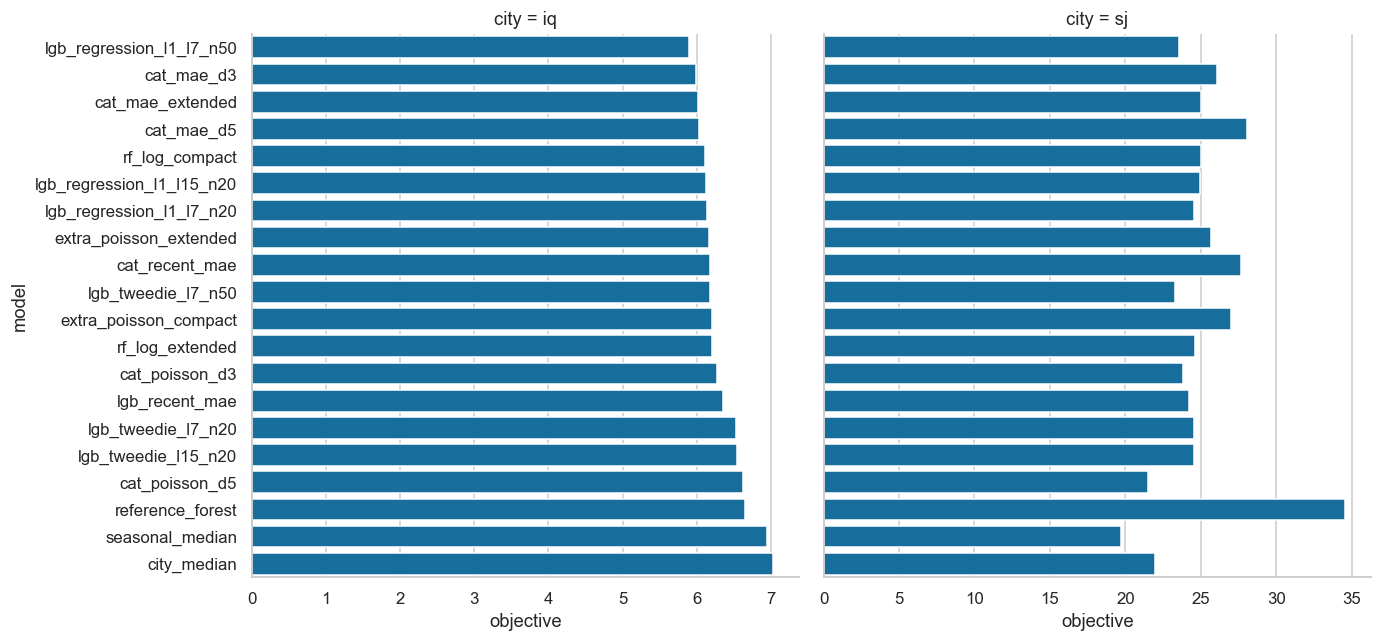

In [7]:
from itertools import combinations
def objective(city, predictions):
    v=city_data[city]
    errors={fold:mae(v['train'][TARGET].iloc[a:b],predictions[fold]) for fold,a,b in v['folds']}
    annual=np.array([x for k,x in errors.items() if k.startswith('annual')])
    value=.5*annual.mean()+.5*errors['long_horizon']+.1*annual.std(ddof=0)
    return float(value),errors

selected,ranking_rows={},[]
for city,v in city_data.items():
    ranked=sorted((objective(city,p)[0],name) for name,p in oof[city].items())
    best_score,best_name=ranked[0]
    best={'components':{best_name:1.},'development_objective':best_score}
    for value,name in ranked:
        ranking_rows.append(dict(city=city,model=name,objective=value,**objective(city,oof[city][name])[1]))
    best_blend=None
    for (_,a),(_,b) in combinations(ranked[:4],2):
        for w in [.25,.5,.75]:
            p={f:w*oof[city][a][f]+(1-w)*oof[city][b][f] for f,_,_ in v['folds']}
            value,_=objective(city,p)
            if best_blend is None or value<best_blend['development_objective']:
                best_blend={'components':{a:w,b:1-w},'development_objective':value}
    if best_blend and best_blend['development_objective']<=best_score-.1:
        best=best_blend
    selected[city]=best
ranking=pd.DataFrame(ranking_rows).sort_values(['city','objective'])
ranking.to_csv(OUT/'development_ranking.csv',index=False)
(OUT/'selected_models.json').write_text(json.dumps(selected,indent=2))
selection_fingerprint=hashlib.sha256(json.dumps(selected,sort_keys=True).encode()).hexdigest()
print('Frozen selection:',json.dumps(selected,indent=2))
display(ranking.groupby('city').head(8).round(3))
sns.catplot(data=ranking,x='objective',y='model',col='city',kind='bar',sharex=False,height=6,aspect=1.05)
savefig('03_development_comparison')

## 7. Historical audit: one multi-year prediction block
Refit selected components on the development prefix, then predict the entire audit horizon without revealing any audit labels to the model. Compare with the rebuilt reference and simple baselines. **Do not change the selection after reading this table.** The block-bootstrap interval below describes conditional error variability for the fixed forecasts; it does not capture model-selection uncertainty or future distribution shift.

In [8]:
audit_rows,audit_preds=[],[]
audit_models={}
for city,v in city_data.items():
    start,stop=v['dev_end'],len(v['train'])
    names=set(selected[city]['components'])|{'reference_forest','city_median','seasonal_median'}
    predictions={}
    audit_models[city]={}
    for name in sorted(names):
        predictions[name],audit_models[city][name]=fit_predict(SPEC[name],city,start,stop)
    predictions['selected']=sum(w*predictions[n] for n,w in selected[city]['components'].items())
    actual=v['train'][TARGET].iloc[start:stop].to_numpy()
    threshold=float(v['train'][TARGET].iloc[:start].quantile(.9))
    outbreak=actual>=threshold
    for name,p in predictions.items():
        rounded=cases(p)
        audit_rows.append(dict(city=city,model=name,n=len(p),mae=mae(actual,p),
                               bias=float(np.mean(rounded-actual)),
                               outbreak_threshold=threshold,
                               outbreak_mae=float(np.mean(np.abs(rounded[outbreak]-actual[outbreak]))) if outbreak.any() else np.nan,
                               outbreak_n=int(outbreak.sum())))
        frame=v['train'].iloc[start:stop][KEYS+[DATE,TARGET]].copy()
        frame['model'],frame['prediction']=name,rounded
        audit_preds.append(frame)
audit_scores=pd.DataFrame(audit_rows)
audit_predictions=pd.concat(audit_preds,ignore_index=True)
for name in ['selected','reference_forest','city_median','seasonal_median']:
    sub=audit_predictions[audit_predictions.model.eq(name)]
    audit_rows.append(dict(city='pooled',model=name,n=len(sub),mae=mae(sub[TARGET],sub.prediction),
                           bias=float((sub.prediction-sub[TARGET]).mean())))
audit_scores=pd.DataFrame(audit_rows)
audit_scores.to_csv(OUT/'audit_scores.csv',index=False)
audit_predictions.to_csv(OUT/'audit_predictions.csv',index=False)
display(audit_scores.round(3))

rng=np.random.default_rng(SEED)
error_by_city={city: np.abs(f[TARGET].to_numpy()-f.prediction.to_numpy())
               for city,f in audit_predictions.query('model == "selected"').groupby('city')}
bootstrap=[]
for _ in range(1000):
    sampled=[]
    for city,e in error_by_city.items():
        length=13
        starts=rng.integers(0,len(e),size=int(np.ceil(len(e)/length)))
        idx=np.concatenate([(np.arange(length)+s)%len(e) for s in starts])[:len(e)]
        sampled.extend(e[idx])
    bootstrap.append(np.mean(sampled))
print('Fixed-forecast 13-week block bootstrap 95% MAE interval:',np.round(np.quantile(bootstrap,[.025,.975]),3))
assert hashlib.sha256(json.dumps(selected,sort_keys=True).encode()).hexdigest()==selection_fingerprint

,city,model,n,mae,bias,outbreak_threshold,outbreak_mae,outbreak_n
0,sj,city_median,260,17.958,0.458,73.0,81.895,19.0
1,sj,reference_forest,260,16.265,10.412,73.0,30.526,19.0
2,sj,seasonal_median,260,16.631,2.277,73.0,72.684,19.0
3,sj,selected,260,16.631,2.277,73.0,72.684,19.0
4,iq,city_median,156,7.692,-5.949,16.0,25.212,33.0
5,iq,lgb_regression_l1_l7_n50,156,7.186,-4.609,16.0,23.182,33.0
6,iq,reference_forest,156,7.321,-4.218,16.0,21.939,33.0
7,iq,seasonal_median,156,7.340,-5.737,16.0,24.182,33.0
8,iq,selected,156,7.186,-4.609,16.0,23.182,33.0
9,pooled,selected,416,13.089,-0.305,NaN,NaN,NaN


Fixed-forecast 13-week block bootstrap 95% MAE interval: [ 9.271 17.385]


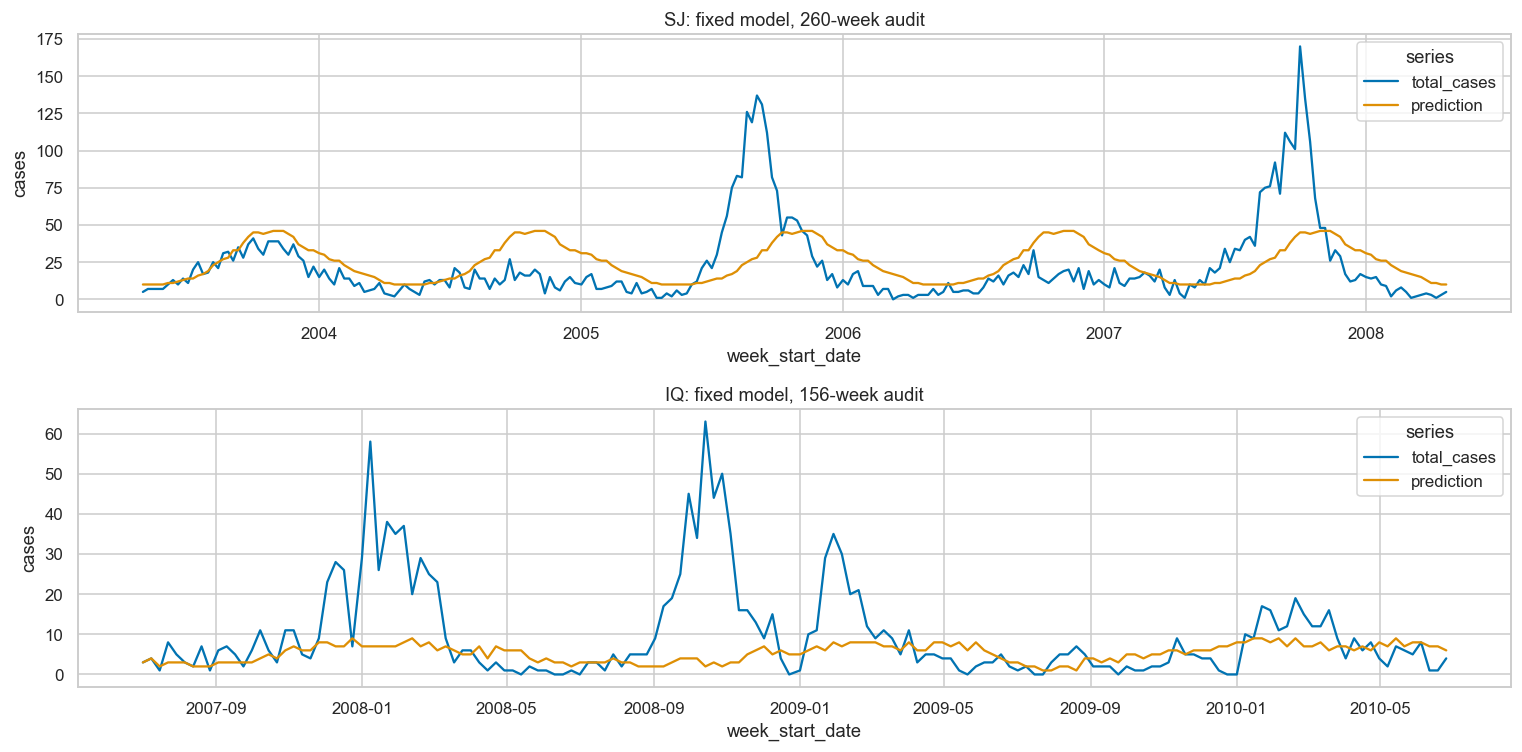

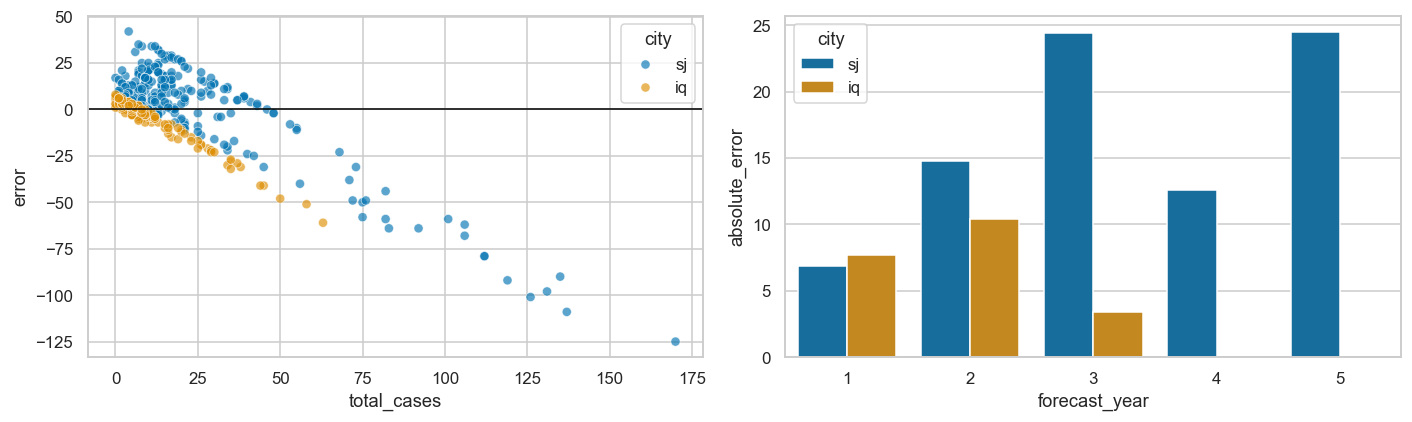

mean  count
city forecast_year               
iq   1               7.712     52
     2              10.423     52
     3               3.423     52
sj   1               6.885     52
     2              14.750     52
     3              24.442     52
     4              12.596     52
     5              24.481     52

In [9]:
fig,axes=plt.subplots(2,1,figsize=(14,7))
for ax,(city,v) in zip(axes,city_data.items()):
    f=audit_predictions.query('city == @city and model == "selected"')
    plot=f.melt(id_vars=DATE,value_vars=[TARGET,'prediction'],var_name='series',value_name='cases')
    sns.lineplot(data=plot,x=DATE,y='cases',hue='series',ax=ax)
    ax.set_title(f'{city.upper()}: fixed model, {len(f)}-week audit')
savefig('04_audit_predictions')
residual=audit_predictions.query('model == "selected"').copy()
residual['error']=residual.prediction-residual[TARGET]
residual['horizon_week']=residual.groupby('city').cumcount()+1
residual['forecast_year']=((residual.horizon_week-1)//52+1).astype(int)
residual['absolute_error']=residual.error.abs()
fig,axes=plt.subplots(1,2,figsize=(13,4))
sns.scatterplot(data=residual,x=TARGET,y='error',hue='city',alpha=.65,ax=axes[0])
axes[0].axhline(0,color='black',lw=1)
sns.barplot(data=residual,x='forecast_year',y='absolute_error',hue='city',errorbar=None,ax=axes[1])
savefig('05_error_diagnostics')
display(residual.groupby(['city','forecast_year']).absolute_error.agg(['mean','count']).round(3))

## 8. Feature contribution: dependence-aware sensitivity
For each city's largest-weight learned component, circularly shift groups of related features together over the audit period. The increase in MAE measures sensitivity to broken alignment, not causal importance. This preserves within-group structure better than independently shuffling every lag, but it remains an approximate diagnostic on correlated time series. It is run **after selection** and never used to prune features or retune the model.

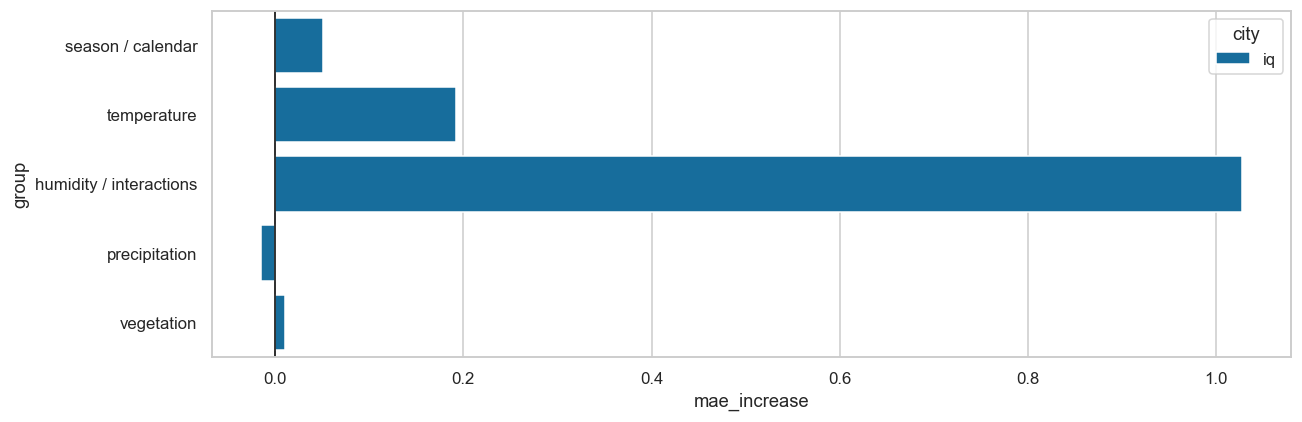

In [10]:
importance_rows=[]
for city,v in city_data.items():
    name=max(selected[city]['components'],key=selected[city]['components'].get)
    s=SPEC[name]
    model=audit_models[city][name]
    if model is None:
        continue
    matrix=v['features'][s['kind']].iloc[v['dev_end']:len(v['train'])].copy()
    actual=v['train'][TARGET].iloc[v['dev_end']:].to_numpy()
    def predict_matrix(m):
        if s['family']=='cat' and s['loss']=='Poisson':
            return model.predict(m,prediction_type='Exponent')
        return model.predict(m)
    base=mae(actual,predict_matrix(matrix))
    groups={
        'season / calendar':[c for c in matrix if c.startswith('week') or c=='year'],
        'temperature':[c for c in matrix if 'temp' in c and 'humidity' not in c],
        'humidity / interactions':[c for c in matrix if 'humidity' in c or 'dew_point' in c],
        'precipitation':[c for c in matrix if 'precip' in c],
        'vegetation':[c for c in matrix if 'ndvi' in c],
    }
    for group,cols in groups.items():
        deltas=[]
        for shift in [13,26,39]:
            perturbed=matrix.copy()
            perturbed.loc[:,cols]=np.roll(matrix[cols].to_numpy(),shift,axis=0)
            deltas.append(mae(actual,predict_matrix(perturbed))-base)
        importance_rows.append(dict(city=city,model=name,group=group,mae_increase=np.mean(deltas)))
importance=pd.DataFrame(importance_rows)
importance.to_csv(OUT/'grouped_sensitivity.csv',index=False)
if len(importance):
    sns.barplot(data=importance,x='mae_increase',y='group',hue='city')
    plt.axvline(0,color='black',lw=1)
    savefig('06_grouped_sensitivity')

## 9. Refit on all labels and export the submission
The selected specifications and weights stay frozen. Refit on all available labeled rows; using the audit labels for this **final training** is appropriate after evaluation. Weather features continue across the train/test boundary, separately by city. Export predictions in the template's exact order, with nonnegative integer counts and no extra index column.

`submission_reference.csv` provides the rebuilt repository architecture for comparison. Neither file has a verified leaderboard score. Submit `submission.csv` on DrivenData, then record the returned score in your project report; repeated leaderboard-driven adjustments would make that score a tuning signal.

In [11]:
final_rows,reference_rows=[],[]
fitted={}
for city,v in city_data.items():
    start,stop=len(v['train']),len(v['train'])+len(v['test'])
    fitted[city]={}
    predicted={}
    for name in sorted(set(selected[city]['components'])|{'reference_forest'}):
        predicted[name],model=fit_predict(SPEC[name],city,start,stop)
        fitted[city][name]={'model':model,'spec':SPEC[name],
                           'feature_columns':list(v['features'][SPEC[name]['kind']].columns),
                           'training_median':float(v['train'][TARGET].median())}
    p=sum(w*predicted[n] for n,w in selected[city]['components'].items())
    for rows,pred in [(final_rows,p),(reference_rows,predicted['reference_forest'])]:
        frame=v['test'][KEYS].copy()
        frame[TARGET]=cases(pred)
        rows.append(frame)

def export_submission(rows,filename):
    pred=pd.concat(rows,ignore_index=True)
    result=template[KEYS].merge(pred,on=KEYS,how='left',validate='one_to_one')
    assert result[KEYS].equals(template[KEYS]) and len(result)==len(raw_test)
    assert result[TARGET].notna().all() and (result[TARGET]>=0).all()
    result[TARGET]=result[TARGET].astype('int64')
    assert list(result.columns)==KEYS+[TARGET]
    result.to_csv(OUT/filename,index=False)
    pd.testing.assert_frame_equal(result,pd.read_csv(OUT/filename))
    return result

submission=export_submission(final_rows,'submission.csv')
reference_submission=export_submission(reference_rows,'submission_reference.csv')
joblib.dump({'models':fitted,'selection':selected,'seed':SEED,
             'climate_columns':CLIMATE,'training_history':train,'test_features':raw_test},OUT/'models.joblib',compress=3)
manifest={'python':platform.python_version(),'versions':versions,'seed':SEED,'quick':QUICK,
          'trees':TREES,'iterations':ITERATIONS,'threads':THREADS,'selected':selected,
          'selection_fingerprint':selection_fingerprint,'leaderboard_score':None,
          'input_sha256':{p.name:hashlib.sha256(p.read_bytes()).hexdigest() for p in sorted(DATA.glob('*.csv'))},
          'submission_sha256':hashlib.sha256((OUT/'submission.csv').read_bytes()).hexdigest()}
(OUT/'run_manifest.json').write_text(json.dumps(manifest,indent=2))
(OUT/'requirements-lock.txt').write_text('\n'.join(f'{p}=={v}' for p,v in versions.items())+'\n')
display(submission.head())
display(submission.groupby('city')[TARGET].agg(['count','mean','median','min','max']).round(2))
print('Submission ready:',OUT/'submission.csv')
print('All integrity checks passed; no file has been uploaded.')

,city,year,weekofyear,total_cases
0,sj,2008,18,7
1,sj,2008,19,8
2,sj,2008,20,8
3,sj,2008,21,10
4,sj,2008,22,10


,count,mean,median,min,max
city,,,,,
iq,156,5.70,6.0,1,11
sj,260,21.76,20.0,7,42


Submission ready: /Users/targaryenaegaer/Documents/DesKTOP/MBZUAI/Project/DengAI/leaderboard_notebook/artifacts/submission.csv
All integrity checks passed; no file has been uploaded.


## 10. Results, applicability, and project defense
The next cell produces a conclusion from the actual executed metrics. Keep unfavorable results: a failed audit improvement is useful evidence about regime shift, not a reason to select on the audit. The old README's leaderboard score is not comparable to a local MAE on different weeks.

**Limitations and next experiments:** small per-city samples; temporally dependent errors; rare outbreaks underpredicted by median-oriented losses; changing reporting or transmission; climate covariates already observed in this competition; no epidemiological mechanism or causal validation. Development windows overlap, the historical audit has been studied in previous workspace experiments, and ensemble selection adds optimism. A clinical deployment would need prospective validation, actual weather forecasts, operational lead times, and explicit costs for missed outbreaks versus overstaffing.

**Impact:** MAE reduction means fewer absolute case-count errors per week, not proven lives saved or reduced spending. To estimate operational benefit, collect staffing/supply cost data and evaluate a pre-specified decision policy prospectively against current practice. Investigate outbreak recall separately if early warning, rather than case estimation, is the operational objective.

**Presentation outline (8–10 minutes):** problem and supplied data; EDA findings; feature availability; chronological folds; model/ensemble selection; audit plots and failure cases; submission and limitations. Each teammate should identify their actual contribution. Add names and the recorded-video URL yourself; those cannot be inferred from model outputs.

In [12]:
pooled=audit_scores.query('city == "pooled"').set_index('model').mae
chosen=float(pooled['selected'])
ref=float(pooled['reference_forest'])
median=float(pooled['city_median'])
relative=100*(median-chosen)/median
direction='lower' if chosen<ref else 'higher'
conclusion=(f'**Historical audit MAE: {chosen:.3f} cases/week.** '
            f'The city-median baseline scored {median:.3f}; relative MAE reduction is {relative:.1f}%. '
            f'The rebuilt forest reference scored {ref:.3f}; the selected model is {abs(ref-chosen):.3f} {direction}. '
            'These are retrospective local scores, not leaderboard results. '
            'The selection remained frozen throughout the audit. '
            'The final submission contains '+str(len(submission))+' validated rows. '
            'Leaderboard performance remains unknown until submission.')
display(Markdown(conclusion))
print('Selected components:',json.dumps({c:s['components'] for c,s in selected.items()},indent=2))

**Historical audit MAE: 13.089 cases/week.** The city-median baseline scored 14.108; relative MAE reduction is 7.2%. The rebuilt forest reference scored 12.911; the selected model is 0.178 higher. These are retrospective local scores, not leaderboard results. The selection remained frozen throughout the audit. The final submission contains 416 validated rows. Leaderboard performance remains unknown until submission.

Selected components: {
  "sj": {
    "seasonal_median": 1.0
  },
  "iq": {
    "lgb_regression_l1_l7_n50": 1.0
  }
}
